# Fusion: poster + text

The poster model in `02_poster_classification.ipynb` scores **0.6175** macro AP. The text model in `01_text_classification.ipynb` scores **0.7268**. Here we check whether combining them beats either one alone.

[LeBaron (Stanford CS230)](http://cs230.stanford.edu/projects_fall_2021/reports/102983714.pdf) fuse four modalities (poster, video, metadata, text) by concatenating output probabilities and training a final fully connected layer on top. We have two modalities, poster and text, so we follow that procedure and also measure the simplest alternative: averaging probabilities.

| Approach | Parameters | How it works |
|---|---|---|
| Mean fusion | 0 | arithmetic mean of the two models' probabilities |
| Late fusion (paper style) | 351 | concatenate 26 probabilities, linear layer, 13 outputs |

Short answer: **mean fusion wins** (0.7479 macro AP), and that is the result we report. The rest of the notebook explains why the trained layer loses to a plain average, and where the poster actually helps the text model.

## 1. Setup

We do not train either base model here. The poster model already saved val and test probabilities in `results/poster/predictions_{val,test}_clip_vit_b32.csv`. The text pipeline exported `models/text_predictions.npz` (section 11 in `01_text_classification.ipynb`). Fusion uses only those numbers.

The practical benefit: fusion runs in seconds on CPU and does not need the CLIP checkpoint (605 MB) or re-vectorizing text. The cost is that predictions must be aligned by `movie_id`. That is why `fusion.data.load_fusion_inputs` sorts poster predictions to match the split label files and raises if a movie is missing.

In [41]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import display

ROOT = Path("..").resolve()
sys.path.insert(0, str(ROOT / "src"))
sys.path.insert(0, str(ROOT))

from fusion.data import load_fusion_inputs
from fusion.late_fusion import LateFusionHead
from fusion.metrics import mean_fusion_scores
from helpers import GENRES, PAPER_RESULTS
from poster.metrics import compute_ap_metrics

FUSION = ROOT / "results" / "fusion"
POSTER = ROOT / "results" / "poster"
TEXT_NPZ = ROOT / "models" / "text_predictions.npz"

try:
    plt.style.use("seaborn-v0_8-whitegrid")
except OSError:
    plt.style.use("ggplot")
plt.rcParams.update({"figure.figsize": (10, 5), "font.size": 11})

## 2. Fusion inputs

Both models need predictions on **two** splits:

- **val (491 movies):** used to train the late fusion layer
- **test (989 movies):** used for the final score, looked at only at the end

Why train fusion on validation, not train? Both base models are overfit on train. Text logistic regression outputs probabilities near 0/1 there, and the poster model has already seen those images. A fusion layer trained on those inputs would learn to trust whichever model looks most confident on train, which says nothing about unseen data. Validation is the only split where both models err realistically, and test stays untouched.

In [42]:
data = load_fusion_inputs(
    TEXT_NPZ,
    "logreg",
    POSTER / "predictions_val_clip_vit_b32.csv",
    POSTER / "predictions_test_clip_vit_b32.csv",
)

for key in ("poster_val", "text_val", "poster_test", "text_test"):
    print(f"{key:12s} {data[key].shape}")

y_val, y_test = data["y_val"], data["y_test"]
metrics = json.loads((FUSION / "test_metrics.json").read_text())

poster_val   (491, 13)
text_val     (491, 13)
poster_test  (989, 13)
text_test    (989, 13)


A short check that we are using the same numbers the scripts saved. AP computed here must match `results/fusion/test_metrics.json`. If it does not, `movie_id` alignment broke.

In [43]:
check = pd.DataFrame([
    {
        "model": "Poster (CLIP)",
        "notebook": compute_ap_metrics(y_test, data["poster_test"])["macro_ap"],
        "test_metrics.json": metrics["models"]["poster_only"]["macro_ap"],
    },
    {
        "model": "Text (TF-IDF + LogReg)",
        "notebook": compute_ap_metrics(y_test, data["text_test"])["macro_ap"],
        "test_metrics.json": metrics["models"]["text_only"]["macro_ap"],
    },
]).set_index("model")
check["abs_diff"] = (check["notebook"] - check["test_metrics.json"]).abs()
display(check.round(6))

,notebook,test_metrics.json,abs_diff
model,,,
Poster (CLIP),0.617520,0.617520,0.0
Text (TF-IDF + LogReg),0.726817,0.726817,0.0


## 3. Two ways to combine

**Mean fusion** is the arithmetic mean of probabilities:

\[ p_{\text{fusion}} = \tfrac{1}{2}\left(p_{\text{poster}} + p_{\text{text}}\right) \]

Zero parameters, no training, no use of validation. It works because the two models fail on different movies: the poster misses biography, the text misses animation, so the average reduces both errors. The weakness is that it treats the models as equally good, even though text carries more information (0.7268 vs 0.6175).

**Late fusion** is the paper procedure: concatenate probabilities into a length-26 vector and map it to 13 outputs with a linear layer, using the same weighted BCE as the base models. The layer has 26 x 13 + 13 = **351 parameters**. It can learn that one modality is worth more, and that `animation` should listen to the poster while `crime` should listen to text. The cost is that those parameters are fit on only 491 examples.

In [44]:
mean_test = mean_fusion_scores(data["poster_test"], data["text_test"])

comparison = pd.read_csv(FUSION / "comparison_test.csv", index_col=0)
ours = comparison[~comparison.index.str.contains(r"\(rad\)")].copy()
ours = ours.sort_values("AP_macro", ascending=False)
display(ours[["AP_macro", "AP_micro", "AP_samples", "F1_macro"]].round(4))

print("mean fusion check:", round(compute_ap_metrics(y_test, mean_test)["macro_ap"], 4))

,AP_macro,AP_micro,AP_samples,F1_macro
model,,,,
Mean fusion (poster + text),0.7479,0.7915,0.8618,0.6710
Text (TF-IDF + LogReg),0.7268,0.7733,0.8430,0.6513
Late fusion (clip_vit_b32 + logreg),0.7066,0.7551,0.8332,0.6306
Poster (clip_vit_b32),0.6175,0.6219,0.7416,0.5359


mean fusion check: 0.7479


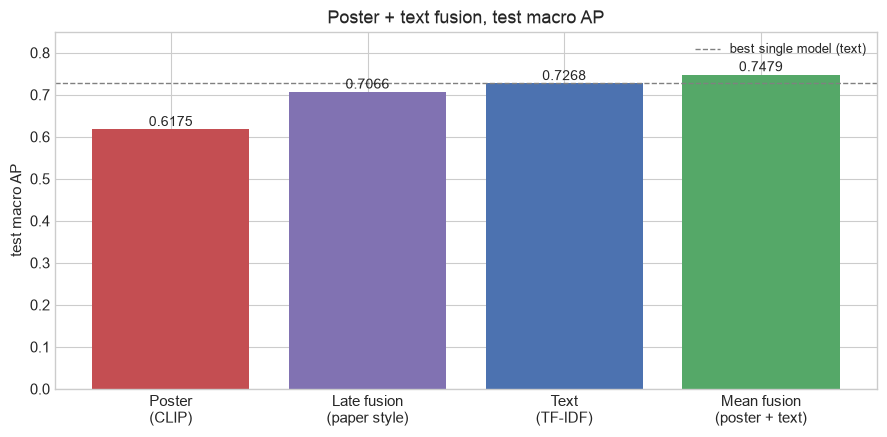

In [45]:
order = ["Poster (clip_vit_b32)", "Late fusion (clip_vit_b32 + logreg)",
         "Text (TF-IDF + LogReg)", "Mean fusion (poster + text)"]
labels = ["Poster\n(CLIP)", "Late fusion\n(paper style)", "Text\n(TF-IDF)", "Mean fusion\n(poster + text)"]
values = [ours.loc[m, "AP_macro"] for m in order]
colors = ["#C44E52", "#8172B2", "#4C72B0", "#55A868"]

fig, ax = plt.subplots(figsize=(9, 4.5))
bars = ax.bar(labels, values, color=colors)
ax.axhline(ours.loc["Text (TF-IDF + LogReg)", "AP_macro"], color="gray",
           linestyle="--", linewidth=1, label="best single model (text)")
for bar, v in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width() / 2, v + 0.008, f"{v:.4f}", ha="center", fontsize=10)
ax.set_ylabel("test macro AP")
ax.set_ylim(0, 0.85)
ax.set_title("Poster + text fusion, test macro AP")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

## 4. Result

| Model | macro AP | vs text |
|---|---|---|
| Mean fusion (poster + text) | **0.7479** | **+0.021** |
| Text (TF-IDF + LogReg) | 0.7268 | 0 |
| Late fusion (paper style) | 0.7066 | -0.020 |
| Poster (CLIP) | 0.6175 | -0.109 |

Two findings:

1. **The poster carries information that is not in the plot.** Plain averaging is +0.021 macro AP over text, even though the poster model alone is much weaker. If the poster were pure noise, averaging would hurt, not help.
2. **The trained fusion layer loses to averaging** (0.7066 vs 0.7479), by more than the poster itself contributes. That needs an explanation, because it is the paper method.

## 5. Why the trained fusion layer loses

The first run scored  0.5245, below both text and mean fusion. That was not a property of the method. It was a training setup bug: the layer is trained **full batch**, one optimizer step per epoch, so the default 100 epochs meant 100 Adam steps. The model was simply not trained.

The plot below is that experiment. We track AP on the data the layer fits (491 val examples) and, for diagnosis, AP on test.

In [51]:
poster_val_t = torch.tensor(data["poster_val"])
text_val_t = torch.tensor(data["text_val"])
y_val_t = torch.tensor(y_val)
poster_test_t = torch.tensor(data["poster_test"])
text_test_t = torch.tensor(data["text_test"])

torch.manual_seed(42)
head = LateFusionHead(n_modalities=2, n_classes=len(GENRES))
criterion = torch.nn.BCEWithLogitsLoss(
    pos_weight=torch.tensor(data["pos_weight"], dtype=torch.float32)
)
optimizer = torch.optim.Adam(head.parameters(), lr=1e-3)

CHECKPOINTS = [100, 250, 500, 1000, 2000, 3000, 5000]
sweep = []

for step in range(1, max(CHECKPOINTS) + 1):
    head.train()
    optimizer.zero_grad()
    loss = criterion(head(poster_val_t, text_val_t), y_val_t)
    loss.backward()
    optimizer.step()

    if step in CHECKPOINTS:
        head.eval()
        with torch.no_grad():
            fit = torch.sigmoid(head(poster_val_t, text_val_t)).numpy()
            tst = torch.sigmoid(head(poster_test_t, text_test_t)).numpy()
        sweep.append({
            "steps": step,
            "loss": loss.item(),
            "AP on val (fit data)": compute_ap_metrics(y_val, fit)["macro_ap"],
            "AP on test": compute_ap_metrics(y_test, tst)["macro_ap"],
        })

sweep_df = pd.DataFrame(sweep).set_index("steps")
display(sweep_df.round(4))

,loss,AP on val (fit data),AP on test
steps,,,
100,0.9862,0.5448,0.5245
250,0.8542,0.6445,0.6317
500,0.7378,0.6773,0.6625
1000,0.6372,0.7108,0.6809
2000,0.5608,0.7457,0.6951
3000,0.5237,0.7609,0.6998
5000,0.4813,0.7797,0.7066


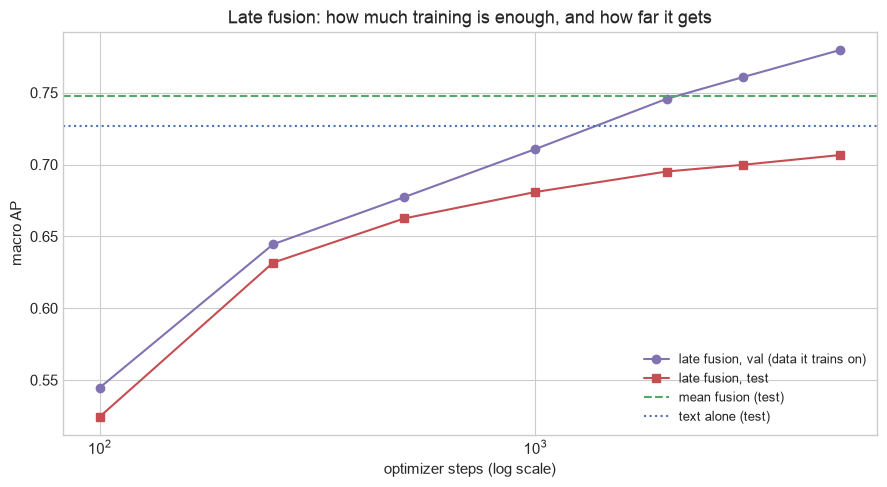

In [52]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(sweep_df.index, sweep_df["AP on val (fit data)"], "o-", color="#8172B2",
        label="late fusion, val (data it trains on)")
ax.plot(sweep_df.index, sweep_df["AP on test"], "s-", color="#C44E52",
        label="late fusion, test")
ax.axhline(ours.loc["Mean fusion (poster + text)", "AP_macro"], color="#55A868",
           linestyle="--", label="mean fusion (test)")
ax.axhline(ours.loc["Text (TF-IDF + LogReg)", "AP_macro"], color="#4C72B0",
           linestyle=":", label="text alone (test)")
ax.set_xscale("log")
ax.set_xlabel("optimizer steps (log scale)")
ax.set_ylabel("macro AP")
ax.set_title("Late fusion: how much training is enough, and how far it gets")
ax.legend(fontsize=9, loc="lower right")
plt.tight_layout()
plt.show()

The curve shows three things.

**The first 100 steps were far from convergence.** From 0.5245 at 100 steps to 0.7066 at 5000 steps: that was undertraining, not a bad method. Default in `scripts/fuse_predictions.py` is now 5000 epochs, and AP is scored every 25 epochs (AP is more expensive than the optimizer step, so scoring every epoch took seven minutes instead of twenty seconds).

**Even a trained layer does not beat averaging.** At 5000 steps, test AP is 0.7066, below mean fusion (0.7479) and below text alone (0.7268), and the curve has already flattened.

**The reason is the gap between the two curves.** At 5000 steps the layer has 0.7797 on the data it trains on, and 0.7066 on test. That 0.07 gap is 351 parameters overfitting 491 examples. With about 1.4 examples per parameter, fusion memorizes both the rule ("trust the poster for animation") and the noise of that particular sample.

One limitation of our implementation: because the layer is trained on validation, we have no third split to pick a checkpoint. `best_val_macro_ap` in the saved metrics is a fit score, not a held-out score. Early stopping therefore never fires; the value rises monotonically. Splitting validation in two would be cleaner, but 491 movies would leave about 245 examples for fusion training and would make the problem worse. Practical conclusion: on this data size, parameter-free fusion is not a compromise. It is the better choice.

## 6. By genre: where the poster actually helps

0.7479 vs 0.7268 macro AP sounds small. The per-genre breakdown shows it is not small. It is concentrated.

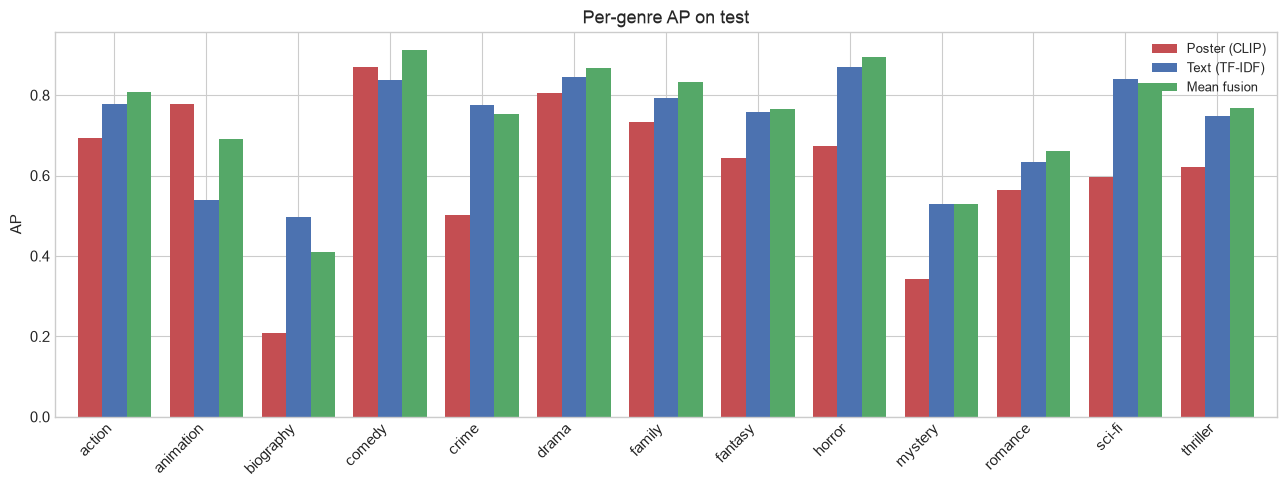

,Poster (CLIP),Text (TF-IDF),Mean fusion,Late fusion
action,0.694,0.779,0.807,0.826
animation,0.777,0.539,0.691,0.533
biography,0.209,0.498,0.410,0.329
comedy,0.870,0.839,0.912,0.904
crime,0.501,0.776,0.752,0.693
drama,0.805,0.845,0.868,0.878
family,0.732,0.792,0.833,0.818
fantasy,0.644,0.759,0.766,0.736
horror,0.674,0.871,0.895,0.864
mystery,0.341,0.530,0.529,0.496


In [48]:
per_genre = pd.DataFrame({
    "Poster (CLIP)": metrics["models"]["poster_only"]["per_genre_ap"],
    "Text (TF-IDF)": metrics["models"]["text_only"]["per_genre_ap"],
    "Mean fusion": metrics["models"]["mean_fusion"]["per_genre_ap"],
    "Late fusion": metrics["models"]["late_fusion"]["per_genre_ap"],
})
per_genre = per_genre.loc[GENRES]

fig, ax = plt.subplots(figsize=(13, 5))
per_genre[["Poster (CLIP)", "Text (TF-IDF)", "Mean fusion"]].plot(
    kind="bar", ax=ax, width=0.8, color=["#C44E52", "#4C72B0", "#55A868"]
)
ax.set_ylabel("AP")
ax.set_title("Per-genre AP on test")
ax.legend(fontsize=9)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

display(per_genre.round(3))

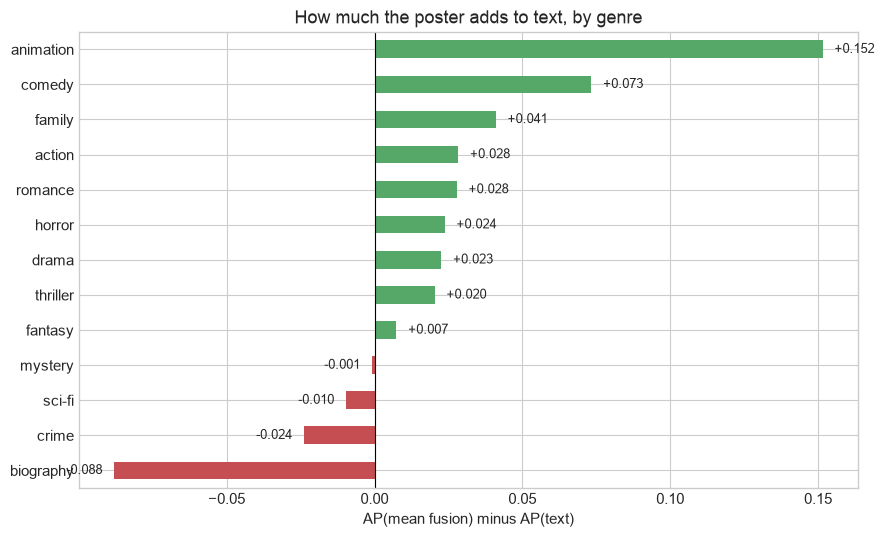

In [49]:
delta = (per_genre["Mean fusion"] - per_genre["Text (TF-IDF)"]).sort_values()
colors = ["#C44E52" if v < 0 else "#55A868" for v in delta]

fig, ax = plt.subplots(figsize=(9, 5.5))
delta.plot(kind="barh", ax=ax, color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("AP(mean fusion) minus AP(text)")
ax.set_title("How much the poster adds to text, by genre")
for i, v in enumerate(delta):
    ax.text(v + (0.004 if v >= 0 else -0.004), i, f"{v:+.3f}",
            va="center", ha="left" if v >= 0 else "right", fontsize=9)
plt.tight_layout()
plt.show()

The effect is very uneven:

- **`animation` +0.152.** Here the poster (0.777) is far better than text (0.539). Drawing style is obvious at a glance, while an animated plot synopsis does not look different from a live-action one. This is the cleanest complementary signal in the project.
- **`comedy` +0.073, `family` +0.041.** Comedy posters have a recognizable language: close-up faces, bright palette, large title.
- **Most other genres between +0.02 and +0.03:** a small, stable gain with no damage.
- **`biography` -0.088.** Here the poster (0.209) actively hurts text (0.498). Biography has no visual signature; a biography poster looks like a drama poster, so averaging with a weak model dilutes a good text prediction. The same, to a lesser degree, holds for `crime` and `sci-fi`.

That is also the limit of a 50/50 average: it cannot listen to the poster on `animation` and ignore it on `biography`. That is exactly what the trained fusion layer should learn, and it does learn it on its own data. 491 examples are not enough to carry it to test.

## 7. Comparison with the paper

The paper reports macro AP per modality and for the four-way combination. Our best result and their numbers, same dataset, same metric:

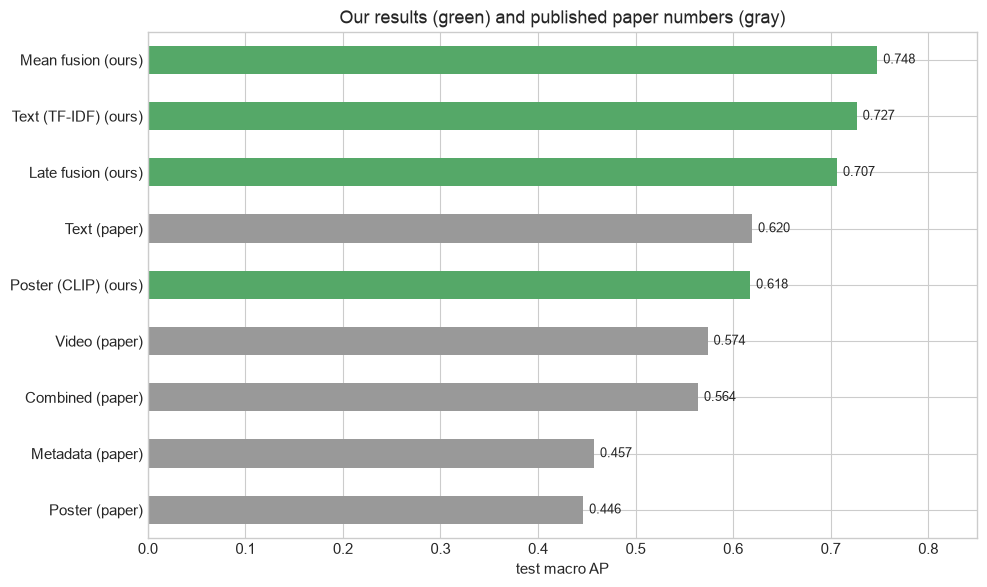

,AP_micro,AP_macro,AP_samples
Poster (paper),0.5201,0.4463,0.6572
Metadata (paper),0.4944,0.4574,0.6284
Combined (paper),0.6270,0.5641,0.7358
Video (paper),0.5899,0.5739,0.6964
Poster (CLIP) (ours),0.6219,0.6175,0.7416
Text (paper),0.6317,0.6195,0.7497
Late fusion (ours),0.7551,0.7066,0.8332
Text (TF-IDF) (ours),0.7733,0.7268,0.8430
Mean fusion (ours),0.7915,0.7479,0.8618


In [53]:
context = PAPER_RESULTS.copy()
context.index = [f"{i.replace(' (rad)', '')} (paper)" for i in context.index]

for label, key in [
    ("Poster (CLIP) (ours)", "poster_only"),
    ("Text (TF-IDF) (ours)", "text_only"),
    ("Late fusion (ours)", "late_fusion"),
    ("Mean fusion (ours)", "mean_fusion"),
]:
    m = metrics["models"][key]
    context.loc[label] = [m["micro_ap"], m["macro_ap"], m["sample_ap"]]

context = context.sort_values("AP_macro")
colors = ["#999999" if "(paper)" in i else "#55A868" for i in context.index]

fig, ax = plt.subplots(figsize=(10, 6))
context["AP_macro"].plot(kind="barh", ax=ax, color=colors)
ax.set_xlabel("test macro AP")
ax.set_title("Our results (green) and published paper numbers (gray)")
for i, v in enumerate(context["AP_macro"]):
    ax.text(v + 0.006, i, f"{v:.3f}", va="center", fontsize=9)
ax.set_xlim(0, 0.85)
plt.tight_layout()
plt.show()

display(context.round(4))

Read the comparison with one limitation: **their combination uses four modalities, ours uses two.** We did not train video or metadata models (trailers are not available as training files; metadata is tabular IMDb fields and was the weakest modality in the paper), so "Combined (paper)" and "Mean fusion (ours)" are not the same thing. With that said:

- Our mean fusion is **0.7479** vs their **0.5641** combined, so +0.18 macro AP with two modalities instead of four. Most of that gap comes from the poster model (CLIP instead of ImageNet VGG, +0.17 on poster alone) and from the text model (TF-IDF + logistic regression instead of GloVe + MLP, +0.11).
- **Their combination was also worse than their best single modality:** Combined 0.5641 vs Text 0.6195. We see the same pattern with the trained fusion layer (0.7066 vs 0.7268 for text). Same method, same outcome, with completely different base models. That supports the explanation that the problem is not model quality, but fitting a final layer on a few hundred examples.
- The difference is that we also measured a parameter-free alternative. It is the only one that actually beats the best single modality.

## 8. Conclusions

1. **Fusion is worth it:** 0.7479 macro AP vs 0.7268 for the best single model. The poster carries information that is not in the plot.
2. **Averaging probabilities is the best combination on this data size.** No parameters, no training, no use of validation, and better than everything else we tried.
3. **The paper's trained fusion layer is not competitive on 491 examples** (0.7066). The first run at 0.5245 was undertraining, but even a trained layer does not beat averaging, because of overfitting visible as 0.7797 vs 0.7066 between fit data and test.
4. **Poster gain is concentrated in visual genres:** `animation` +0.152, `comedy` +0.073, `family` +0.041. On `biography` (-0.088) the poster hurts, because that genre has no visual signature.
5. **Same-modality, we are above the paper** (CLIP poster vs their poster, TF-IDF vs their GloVe MLP). Combination vs combination is not the same comparison: they fuse four modalities, we fuse two.

### Reproduction

```bash
# 1. text predictions: notebooks/01_text_classification.ipynb, section 11
#    -> models/text_predictions.npz
# 2. poster predictions for val and test
python scripts/predict.py --backbone clip_vit_b32 --split-dir val_data --device mps --batch-size 16
python scripts/predict.py --backbone clip_vit_b32 --split-dir test_data --device mps --batch-size 16
# 3. fusion
python scripts/fuse_predictions.py --device cpu
```